<img src="recursos/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 4

Docentes: *LLAMEDO SORIA, Mariano* y *MOHAROS, David*

Autor: *MARCHESI, Matías Sebastián*


## Introducción

En esta tarea se busca obtener las funciones de transferencia de filtros Bessel de órdenes 2, 3 y 4, normalizados para un retardo de grupo en continua unitario, utilizando el método de Storch.

Una vez obtenidas las transferencias, se seleccionará aquella de mínimo orden que cumpla con la atenuación máxima requerida por la plantilla propuesta.

Con la transferencia elegida se evaluará el retardo de grupo a la frecuencia especificada y se determinará el error porcentual respecto al valor de referencia en continua.

Posteriormente se realizará la síntesis del circuito normalizado mediante estructuras Sallen-Key con ganancia unitaria, obteniendo los valores de los componentes necesarios para implementar el filtro.

Finalmente, se verificará el comportamiento del diseño mediante simulaciones numéricas y circuitales, comparando los resultados obtenidos con las especificaciones de la plantilla. Como etapa adicional, se realizará la desnormalización del circuito para alcanzar el retardo de grupo requerido y se validará nuevamente su funcionamiento mediante simulación.

## Obtención de la transferencia usando método de Storch

El objetivo de la aproximación Bessel-Thomson es obtener un filtro pasabajos que de un retardo ($D$) constante por la mayor cantidad de $\omega$ posibles. O sea, $\frac{\partial{D_n(\omega)}}{\partial{\omega}} = 0$ cuando $\omega = 0$. Y a su vez, $D_n(0) = 1$.

Basándose en lo escrito en el libro Design of Analog Filters de Schaumann, en el capítulo 10 sección 2, habla sobre como calcular mediante este método Storch una transferencia de distintos órdenes.

Para la misma se utilizan identidades hiperbólicas obteniendo una función transferencia:

$$T(s) = \frac{1}{e^s} = \frac{1}{senh(s) + cosh(s)}=\frac{1/senh(s)}{1+coth(s)}$$

Y escribiendo las series quedan:

$$\large cosh(s) = 1 + \frac{s^2}{2!} + \frac{s^4}{4!} + \frac{s^6}{6!} + \dots = \sum_{n=0}^{\infty} \frac{s^{2n}}{(2n)!}$$

$$\large senh(s) = s + \frac{s^3}{3!} + \frac{s^5}{5!} + \frac{s^7}{7!} + \dots = \sum_{n=0}^{\infty} \frac{s^{2n+1}}{(2n+1)!}$$

$$\large coth(s) = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{5}{s} + \frac{1}{\frac{7}{s} + \dots }}}$$

Continuando con el desarrollo del libro, se le llama llama a la sumatoria de los términos del numerador y del denominador de la $coth(s)$, $B_n$. El mismo se puede expresar genéricamente como:

$$B_n = (2n - 1) .B_{n-1} + s^2.B_{n-2}$$

Quedando la $T(s)$:

$$T(s) = \frac{B_n(0)}{B_n(s)}$$

### Para n = 1

$$B_1 = 1 + s$$

$$B_1(0) = 1$$

$$T_1(s) = \frac{1}{1+s}$$

### Para n = 2

$$B_2 = 3B_1 + s^2B_0$$

$$B_2 = 3(1+s) + s^2$$

$$B_2 = s^2 + 3s + 3$$

$$B_2(0) = 3$$

$$T_2(s) = \frac{3}{s^2 + 3s + 3}$$

### Para n = 3

$$B_3 = 5B_2 + s^2B_1$$

$$B_3 = 5(s^2 + 3s + 3) + s^2(s+1)$$

$$B_3 = s^3 + 6s^2 + 15s + 15$$

$$B_3(0) = 15$$

$$T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

### Para n = 4

$$B_4 = 7B_3 + s^2 B_2$$

$$B_4 = 7(s^3 + 6s^2 + 15s + 15) + s^2 (s^2 + 3s + 3)$$

$$B_4 = s^4 + 10s^3 + 45s^2 + 105s + 105$$

$$B_4(0) = 105$$

$$T_4(s) = \frac{105}{s^4 + 10s^3 + 45s^2 + 105s + 105}$$

Finalmente, a modo de resumen se colocan las tres transferencias juntas:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$\large T_2(s) = \frac{3}{s^2 + 3s + 3}$$
        $$\large T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$
        $$\large T_4(s) = \frac{105}{s^4 + 10s^3 + 45s^2 + 105s + 105}$$
    </div>
</div>

## Determinando el orden mínimo que cumpla con la plantilla

Se parte de la siguiente plantilla:

<div style="text-align: center;">
  <img src="recursos/plantilla.png" width="450">
</div>

Para determinar el n mínimo que cumpla con el $\alpha_{max}$ utilizo la siguiente ecuación también obtenida del libro antes mencionado.

$$\alpha(\omega_p) = 20log(\frac{1}{|T(j\omega_p)|})$$

O lo que es lo mismo:

$$\alpha(\omega_p) = -20log(|T(j\omega_p)|)$$

Para saber cual es el $n$ mínimo que cumple con las condiciones necesito que $\alpha(\omega_p) <= \alpha_{max}$

Se hace el cálculo para cada caso

### Para n = 2
Considerando $T_2(s)\mid_{s=j\omega;\ \omega = 1}$

$$T_2(j.1) = \frac{3}{-1 + 3j.1 + 3}$$

$$|T_2(j.1)| = \frac{3}{\sqrt{2^2 + 3^2}} = 0.832$$

$$\alpha(\omega_p) = -20log(|T_2(j\omega_p)|) = 1.597dB$$

Como no es menor o igual a $\alpha_{max}$ tengo que seguir iterando.

### Para n = 3

$$T_3(j.1) = \frac{15}{-j -6 + 15j + 15}$$

$$|T_3(j.1)| = \frac{15}{\sqrt{9^2 + 14^2}} = 0.9013$$

$$\alpha(\omega_p) = -20log(|T_3(j\omega_p)|) = 0.903dB$$

Como ese valor es menor que el $\alpha_{max}$ ya sé que el mismo cumple. Entonces el orden mínimo necesario para cumplir con las condiciones del ejercicio es **orden 3**.

## Retardo de grupo

Para evaluar el retardo de grupo tengo que, utilizando $T_3(s)$, derivar la fase de la misma evaluando el caso de $s=j\omega$:

$$T_3(s)\mid_{s=j\omega} = \frac{15}{-j\omega^3-6\omega^2+j15\omega + 15}$$

Defino la fase de la $T_3(s)$ como $\theta(\omega)$.

$$\theta(\omega) = arctg(\frac{0}{15}) - arctg(\frac{15\omega - \omega^3}{15-6\omega^2})$$

$$\theta(\omega) = - arctg(\frac{15\omega - \omega^3}{15-6\omega^2})$$

Defino el retardo como $D(\omega) = -\frac{\partial{\theta(\omega)}}{\partial{\omega}}$

$$D(\omega) = \frac{\partial}{\partial{\omega}}(arctg(\frac{15\omega - \omega^3}{15 - 6\omega^2}))$$

Resolviendo la derivada mediante una calculadora de derivadas se obtiene:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$D(\omega) = \frac{3(2\omega^4 + 15\omega^2 + 75)}{\omega^6 + 6\omega^4 + 45\omega^2 + 225}$$
    </div>
</div>

Ahora, evalúo los casos pedidos en la consigna

$$D(\omega = 0) = \frac{3(75)}{225} = \frac{225}{225} = 1$$

$$D(\omega = 2.5) = 0.7521$$

Calculando el porcentaje de desvío a respecto a $D(\omega = 0)$:

$$\% Desvio = \frac{D(2.5) - D(0)}{D(0)} . 100\%$$

$$\% Desvio = -24.79\%$$

Esto significa que el retardo de grupo en $\omega = 2.5$ es un $24.79\%$ menor que el retardo en $\omega = 0$.

### Obtención en Python del retardo de grupo

Usando la biblioteca de pytc2, se muestra el gráfico del retardo de grupo obtenido usando la función GroupDelay. Con esto se podrá verificar la caída del casi 25% en el gráfico.

Adicionalmente, se muestran el módulo y fase de la transferencia para comparar luego con LTSpice.

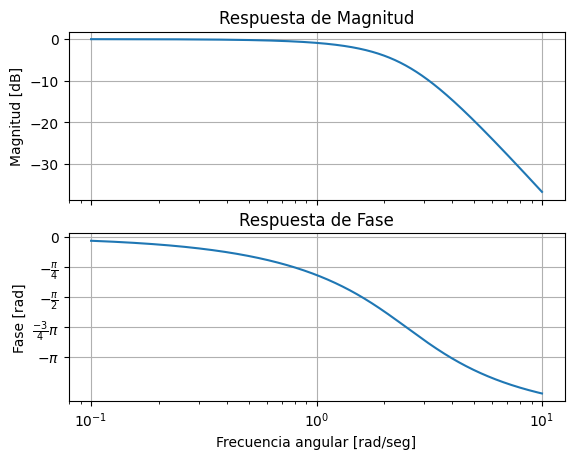

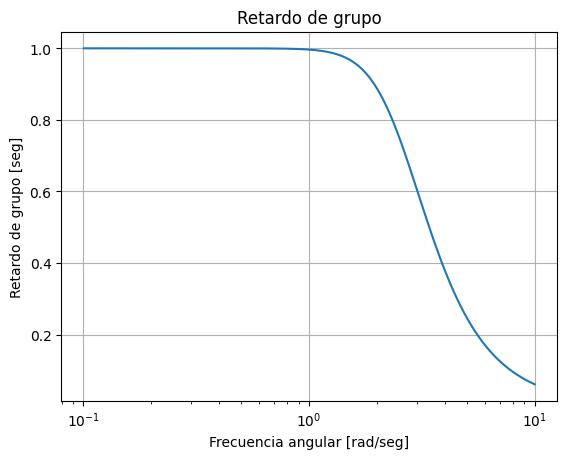

In [2]:
import scipy.signal as sig
import matplotlib.pyplot as plt

from pytc2.sistemas_lineales import bodePlot, GroupDelay

num = [15]
den = [1, 6, 15, 15]

T = sig.TransferFunction(num, den)

bodePlot(T, fig_id=1)

GroupDelay(T, fig_id=2)

plt.show()

### Comprobación del desvío obtenido

Concentrándonos en el retardo de grupo se coloca nuevamente la imagen pero esta vez analizando cuanto vale el desvío en $\omega = 2.5$.

<div style="text-align: center;">
  <img src="recursos/retardo_python.png" width="550">
</div>

Se pide al observador fijarse en la **parte superior derecha de la imagen**, donde se ve en formato (x,y) siendo **x** el $\omega$ y el **y** el desvío en ese punto.

Como se puede ver aproximadamente en $\omega = 2.5$ se obtiene un $D(\omega = 2.5) \approx 0.75$ y teóricamente había dado $0.7521$.

## Sintetización del circuito con Sallen Key

Partiendo de la transferencia: 

$$T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

La expreso de manera FOS + SOS. Para mayor facilidad utilizo un script de Python que me de los polos compuestos conjugados y el polo real.

In [2]:
import numpy as np

polos = np.roots([1,6,15,15])

print("Polo 1 =", polos[0])
print("Polo 2 =", polos[1])
print("Polo 3 =", polos[2])

Polo 1 = (-1.8389073226869548+1.7543809597837214j)
Polo 2 = (-1.8389073226869548-1.7543809597837214j)
Polo 3 = (-2.3221853546260856+0j)


Los polos finalmente son:

$$P1,P2 = P1,P1* = (-1.8389073226869548 \pm j 1.7543809597837214)$$
$$P3 = (-2.3221853546260856)$$

Divido la $T_3(s)$ como las dos transferencias antes mencionadas.

$$
T_3(s) =
{\color{green}{
\underbrace{\frac{|P3|}{s + |P3|}}_{T_{\mathrm{FOS}}(s)}
}
}
\cdot
{\color{blue}
\underbrace{\frac{|P1|^2}{s^2 + |2\operatorname{Re}(P1)| + |P1|^2}}_{T_{\mathrm{SOS}}(s)}
}
$$

Los valores quedarían:

$$T_{FOS}(s) = \frac{2.3222}{s+2.3222}$$

$$T_{SOS}(s) = \frac{6.4594}{s^2 + 3.6778s + 6.4594}$$

### SOS

Para la SOS usaré la configuración Sallen-Key con $K=1$. Utilizo lo que ya resolví en la Tarea Semanal 2, que es la transferencia genérica del Sallen-Key.

<div style="text-align: center;">
  <img src="recursos/sallenkey.png" width="450">
</div>

$$\large T_{SK}(s) = K \cdot \frac{\frac{1}{R1R2C1C2}}{s^2 + s(\frac{C1G1+C1G2+C2G2(1-K)}{C1C2}) + \frac{1}{R1R2C1C2}}$$

Lo expreso adecuándolo a mi caso:

$$T_{SK}(s) = K \cdot \frac{\frac{1}{R1R2C1C2}}{s^2 + s(\frac{C1G1+C1G2}{C1C2}) + \frac{1}{R1R2C1C2}}$$

Comparándolo con la SOS obtengo:

$$\frac{\omega_o}{Q} = 3.6778 = \frac{C1G1+C1G2}{C1C2}$$

$$\omega_o^2 = 6.4594 = \frac{1}{R1R2C1C2}$$

Defino la norma de impedancia para quitar grados de libertad $\omega_z = R1 = R2 = 1$ y reemplazo:

$$\frac{\omega_o}{Q} = 3.6778 = \frac{2C1}{C1C2} = \frac{2}{C2}$$

$$C2 = 0.5438 F$$

Despejo $C1$:

$$\omega_o^2 = \frac{1}{C1C2}$$

$$C1 = \frac{1}{\omega_o^2 \cdot C2}$$

$$C1 = 0.2847 F$$

Los valores son:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$R1 = 1\Omega$$
        $$R2 = 1\Omega$$
        $$C1 = 0.2847F$$
        $$C2 = 0.5438F$$
    </div>
</div>

### FOS

La primer etapa no puedo hacerla con un Sallen-Key ya que es de primer orden. Entonces lo hago con un circuito RC.

<div style="text-align: center;">
  <img src="recursos/circuitoRC.png" width="250">
</div>

$$T_{RC}(s) = \frac{\frac{1}{sC}}{R+\frac{1}{sC}} = \frac{1}{1+sRC} = \frac{\frac{1}{RC}}{s+\frac{1}{RC}}$$

Siendo $\frac{1}{RC} = \omega_o$.

Comparando con la $T_{FOS}(s)$:

$$\omega_o = 2.3222 = \frac{1}{RC}$$

Tomo como norma de impedancia $\omega_z = R = 1$.

Entonces despejo C:
$$C = \frac{1}{\omega_o \cdot R}$$
$$C = 430.63mF$$

Los valores son:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$R = 1\Omega$$
        $$C = 430.63mF$$
    </div>
</div>

### Simulación

Ahora, simulo el circuito con LTSpice:

<div style="text-align: center;">
  <img src="recursos/circuito_normalizado_convalores.png" width="500">
</div>

Para evitar errores de typeo utilizo los parámetros de spice, los mismos son: 
```.param norm_z=1 R_SK={norm_z} wo_q=3.6778 C2_SK={2/wo_q} wo2_2={6.4594} C1_SK={1/(wo2_2*C2_SK)}```
```.param R={norm_z} wo1={2.3222} C={1/wo1*R}```

Se simula la respuesta en frecuencia con la directiva `.ac dec 10000 1u 100` y colocando un generador como entrada de $V_i$ y obtengo:

#### Módulo
<div style="text-align: center;">
  <img src="recursos/modulo_grafico.png" width="400">
</div>

#### Fase
<div style="text-align: center;">
  <img src="recursos/fase_grafico.png" width="400">
</div>

#### Retardo de grupo

<div style="text-align: center;">
  <img src="recursos/retardo_grafico.png" width="400">
</div>

Para demostrar que obtuve el mismo retardo de grupo que el calculado utilizo cursores para ver el valor en $D(\omega = 2.5)$.

<div style="text-align: center;">
  <img src="recursos/retardo_cursor_y_grafico.png" width="500">
</div>

Y como resalté en azul, a los $397mHz$ obtengo $752.17mS$. Este valor es el obtenido analíticamente anteriormente.

Utilicé el valor de $397mHz$ ya que es el resultado de hacer $\frac{2.5}{2\pi} = f = 397.88mHz$